### Task 1 - Implementation and Algorithm Trace

Original array: A = [5, 2, 4, 7, 1, 3, 2, 6]

Code:


In [1]:
def merge_sort(A):
    if len(A) <= 1:
        return A

    mid = len(A) // 2
    left = A[:mid]
    right = A[mid:]

    print("Divide:", A, "->", left, "and", right)

    left = merge_sort(left)
    right = merge_sort(right)

    result = merge(left, right)

    print("Merge:", left, "+", right, "->", result)

    return result


def merge(left, right):
    result = []
    i = 0
    j = 0

    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])

    return result


A = [5, 2, 4, 7, 1, 3, 2, 6]

print("Original array:", A)
print()

sorted_array = merge_sort(A)

print()
print("Final sorted array:", sorted_array)

Original array: [5, 2, 4, 7, 1, 3, 2, 6]

Divide: [5, 2, 4, 7, 1, 3, 2, 6] -> [5, 2, 4, 7] and [1, 3, 2, 6]
Divide: [5, 2, 4, 7] -> [5, 2] and [4, 7]
Divide: [5, 2] -> [5] and [2]
Merge: [5] + [2] -> [2, 5]
Divide: [4, 7] -> [4] and [7]
Merge: [4] + [7] -> [4, 7]
Merge: [2, 5] + [4, 7] -> [2, 4, 5, 7]
Divide: [1, 3, 2, 6] -> [1, 3] and [2, 6]
Divide: [1, 3] -> [1] and [3]
Merge: [1] + [3] -> [1, 3]
Divide: [2, 6] -> [2] and [6]
Merge: [2] + [6] -> [2, 6]
Merge: [1, 3] + [2, 6] -> [1, 2, 3, 6]
Merge: [2, 4, 5, 7] + [1, 2, 3, 6] -> [1, 2, 2, 3, 4, 5, 6, 7]

Final sorted array: [1, 2, 2, 3, 4, 5, 6, 7]


Question: 1. What is the base case of the Merge Sort algorithm?

##### The base case is when the array contains one element or no elements. Such an array is already sorted..

Question: 2. At what point does the recursion stop?

##### The recursion stops when the array is divided into subarrays containing one element each.

Question: 3. What is the purpose of the Merge procedure?

##### The purpose of the Merge procedure is to combine two already sorted subarrays into one sorted array.

### Task 2 - Modified Merge Sort

Original array: A = [12, 5, 8, 1, 19, 4, 15, 7]

Expected result: [19, 15, 12, 8, 7, 5, 4, 1]

Code:


In [2]:
def merge_sort(A):
    if len(A) <= 1:
        return A

    mid = len(A) // 2
    left = A[:mid]
    right = A[mid:]

    print("Divide:", A, "->", left, "and", right)

    left = merge_sort(left)
    right = merge_sort(right)

    result = merge(left, right)

    print("Merge:", left, "+", right, "->", result)

    return result


def merge(left, right):
    result = []
    i = 0
    j = 0

    while i < len(left) and j < len(right):
        if left[i] >= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])

    return result


A = [12, 5, 8, 1, 19, 4, 15, 7]

print("Original array:", A)
print()

sorted_array = merge_sort(A)

print()
print("Final sorted array:", sorted_array)

Original array: [12, 5, 8, 1, 19, 4, 15, 7]

Divide: [12, 5, 8, 1, 19, 4, 15, 7] -> [12, 5, 8, 1] and [19, 4, 15, 7]
Divide: [12, 5, 8, 1] -> [12, 5] and [8, 1]
Divide: [12, 5] -> [12] and [5]
Merge: [12] + [5] -> [12, 5]
Divide: [8, 1] -> [8] and [1]
Merge: [8] + [1] -> [8, 1]
Merge: [12, 5] + [8, 1] -> [12, 8, 5, 1]
Divide: [19, 4, 15, 7] -> [19, 4] and [15, 7]
Divide: [19, 4] -> [19] and [4]
Merge: [19] + [4] -> [19, 4]
Divide: [15, 7] -> [15] and [7]
Merge: [15] + [7] -> [15, 7]
Merge: [19, 4] + [15, 7] -> [19, 15, 7, 4]
Merge: [12, 8, 5, 1] + [19, 15, 7, 4] -> [19, 15, 12, 8, 7, 5, 4, 1]

Final sorted array: [19, 15, 12, 8, 7, 5, 4, 1]


Question: 1. What comparison was changed?

##### For decreasing: if left[i] >= right[j]:

Question: 2. Why does this produce decreasing order?

##### After the recursive division, each half is already sorted in descending order. Then, merge() compares the first elements of the two halves.

### Task 3 - Counting Comparisons 

Code:


In [7]:
def merge_sort(A):
    comparisons = 0

    def merge(left, right):
        nonlocal comparisons

        result = []
        i = 0
        j = 0

        while i < len(left) and j < len(right):
            comparisons += 1

            if left[i] <= right[j]:
                result.append(left[i])
                i += 1
            else:
                result.append(right[j])
                j += 1

        result.extend(left[i:])
        result.extend(right[j:])

        return result

    def sort(A):
        if len(A) <= 1:
            return A

        mid = len(A) // 2

        left = sort(A[:mid])
        right = sort(A[mid:])

        return merge(left, right)

    sorted_array = sort(A)

    return sorted_array, comparisons


A1 = [1, 2, 3, 4, 5, 6, 7, 8]
A2 = [8, 7, 6, 5, 4, 3, 2, 1]
A3 = [7, 2, 8, 4, 1, 6, 5, 3]

result1, comparisons1 = merge_sort(A1)
result2, comparisons2 = merge_sort(A2)
result3, comparisons3 = merge_sort(A3)

print("Sorted array:")
print(result1)
print("Comparisons:", comparisons1)

print("\nReverse-sorted array:")
print(result2)
print("Comparisons:", comparisons2)

print("\nRandom array:")
print(result3)
print("Comparisons:", comparisons3)

Sorted array:
[1, 2, 3, 4, 5, 6, 7, 8]
Comparisons: 12

Reverse-sorted array:
[1, 2, 3, 4, 5, 6, 7, 8]
Comparisons: 12

Random array:
[1, 2, 3, 4, 5, 6, 7, 8]
Comparisons: 16


1. Does Merge Sort behave as differently as Insertion Sort for sorted and reverse-sorted inputs?
No.

Insertion Sort behaves very differently:

Sorted array → very few comparisons and shifts.
Reverse-sorted array → many comparisons and shifts.

Merge Sort performs almost the same number of comparisons for both sorted and reverse-sorted arrays.

2. Which input required the largest number of comparisons?

The random-order array required the largest number of comparisons:

16 comparisons.

The sorted and reverse-sorted arrays both required 12 comparisons.

3. Why does input order have less influence on Merge Sort than on Insertion Sort?

Merge Sort always follows approximately the same process:

Divide the array into two halves.
Continue dividing until there is one element in each subarray.
Merge the subarrays back together.
During merging, compare elements from the two sorted parts.

### Task 4 - Experimental Analysis and Comparison

Code:


n = 100, average time = 0.000231 seconds
n = 500, average time = 0.001184 seconds
n = 1000, average time = 0.002212 seconds
n = 5000, average time = 0.010870 seconds
n = 10000, average time = 0.021832 seconds
n = 50000, average time = 0.149495 seconds


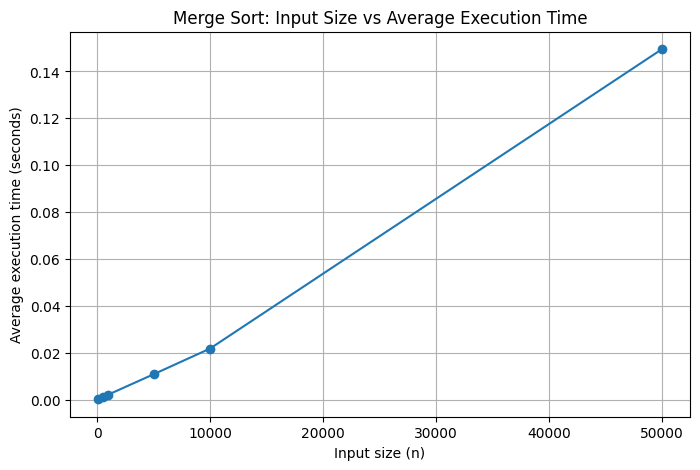

In [10]:
import random
import time
import matplotlib.pyplot as plt


def merge_sort(arr):
    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2

    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])

    result = []
    i = 0
    j = 0

    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])

    return result

sizes = [100, 500, 1000, 5000, 10000, 50000]

merge_times = []

for n in sizes:
    times = []

    for _ in range(5):
        arr = [random.randint(1, 100000) for _ in range(n)]

        start = time.perf_counter()
        merge_sort(arr)
        end = time.perf_counter()

        times.append(end - start)

    average_time = sum(times) / len(times)
    merge_times.append(average_time)

    print(f"n = {n}, average time = {average_time:.6f} seconds")

plt.figure(figsize=(8, 5))

plt.plot(sizes, merge_times, marker='o')

plt.xlabel("Input size (n)")
plt.ylabel("Average execution time (seconds)")
plt.title("Merge Sort: Input Size vs Average Execution Time")

plt.grid(True)
plt.show()

In [11]:
comparison_sizes = [100, 500, 1000, 5000, 10000]

insertion_times = []
merge_times_comparison = []

for n in comparison_sizes:
    insertion_run_times = []
    merge_run_times = []

    for _ in range(5):
        arr = [random.randint(1, 100000) for _ in range(n)]

        arr1 = arr.copy()
        arr2 = arr.copy()

        start = time.perf_counter()
        insertion_sort(arr1)
        end = time.perf_counter()

        insertion_run_times.append(end - start)

        start = time.perf_counter()
        merge_sort(arr2)
        end = time.perf_counter()

        merge_run_times.append(end - start)

    insertion_average = sum(insertion_run_times) / 5
    merge_average = sum(merge_run_times) / 5

    insertion_times.append(insertion_average)
    merge_times_comparison.append(merge_average)

    print(
        f"n = {n}, "
        f"Insertion Sort = {insertion_average:.6f}s, "
        f"Merge Sort = {merge_average:.6f}s"
    )

n = 100, Insertion Sort = 0.000297s, Merge Sort = 0.000198s
n = 500, Insertion Sort = 0.006133s, Merge Sort = 0.000876s
n = 1000, Insertion Sort = 0.021119s, Merge Sort = 0.001626s
n = 5000, Insertion Sort = 0.544507s, Merge Sort = 0.010331s
n = 10000, Insertion Sort = 2.160344s, Merge Sort = 0.021649s


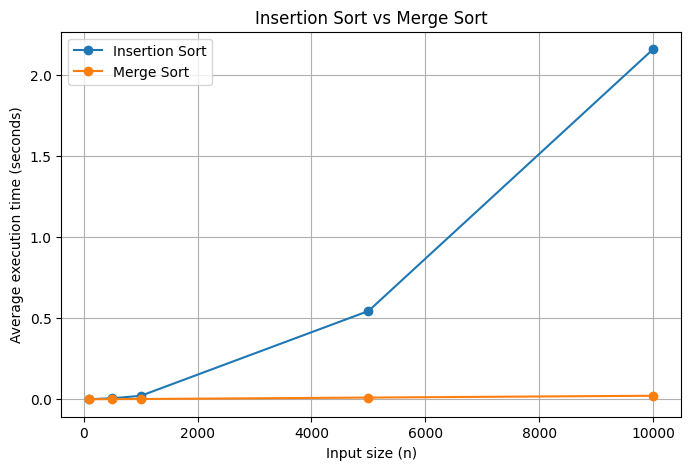

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    comparison_sizes,
    insertion_times,
    marker='o',
    label="Insertion Sort"
)

plt.plot(
    comparison_sizes,
    merge_times_comparison,
    marker='o',
    label="Merge Sort"
)

plt.xlabel("Input size (n)")
plt.ylabel("Average execution time (seconds)")
plt.title("Insertion Sort vs Merge Sort")

plt.legend()
plt.grid(True)
plt.show()

1. What happens to the execution time of Merge Sort as n increases?

As the input size n increases, the execution time of Merge Sort also increases. However, the increase is relatively slow because Merge Sort has a time complexity of O(n log n).

2. Which algorithm becomes faster for larger arrays?

Merge Sort becomes faster for larger arrays. Insertion Sort becomes significantly slower as the input size increases.

3. At approximately what input size does the difference become clearly visible?

In my experiment, the difference became clearly visible at approximately n = 5000. Merge Sort required much less time than Insertion Sort.

4. Why does Merge Sort scale better than Insertion Sort?

Merge Sort has a time complexity of O(n log n), while Insertion Sort has a time complexity of O(n²) for average and worst-case inputs. Therefore, when the input size becomes large, Merge Sort grows much more slowly in execution time.

5. Would you choose Merge Sort or Insertion Sort for one million randomly ordered elements?

I would choose Merge Sort for an array containing one million randomly ordered elements. Merge Sort has O(n log n) time complexity, while Insertion Sort has O(n²) average and worst-case complexity. For such a large array, Insertion Sort would require significantly more operations and would be much slower.



### Conclusion

In this assignment, I learned how Merge Sort works and how the divide-and-conquer approach can be used to solve sorting problems. Merge Sort divides an array into smaller parts, sorts them, and then merges them back together. I also learned how to measure the execution time of an algorithm and compare it with Insertion Sort. The experiment showed that Merge Sort scales better for large arrays because it has a time complexity of Θ(n log n), while Insertion Sort has Θ(n²) average and worst-case complexity.
